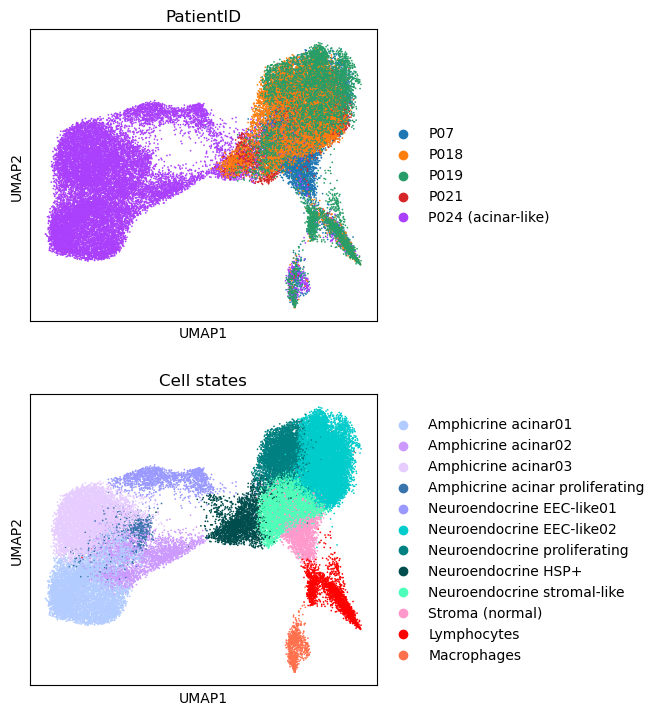

In [1]:
import scanpy as sc
import pandas as pd
import os

adata= sc.read_h5ad("./celltypist_benchmark/pNEC_updated_annot_07082023.h5ad")

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']= (4,4)

sc.pl.umap(adata, color= ['PatientID', 'Cell states'], size=6, ncols=1)

In [2]:
#Rename PatientID labels
adata.obs['PatientID'] = adata.obs['PatientID'].replace({
    'P07': 'P1',
    'P018': 'P2',
    'P019': 'P3',
    'P021': 'P4',
    'P024 (acinar-like)': 'P5 (acinar)'
})


print(adata.obs['PatientID'].value_counts()) 

#Rename Cell states labels
adata.obs['Cell states'] = adata.obs['Cell states'].replace({
    'Neuroendocrine EEC-like01': 'Amphicrine progenitor-like',
    'Neuroendocrine EEC-like02': 'Neuroendocrine',
    'Neuroendocrine HSP+': 'Neuroendocrine HSP+ (hypoxic)'
})

print(adata.obs['Cell states'].value_counts()) 

PatientID
P5 (acinar)    19497
P1              8768
P2              8314
P3              5580
P4              2856
Name: count, dtype: int64
Cell states
Neuroendocrine                     10095
Amphicrine acinar01                 7047
Amphicrine acinar03                 5840
Neuroendocrine stromal-like         5668
Neuroendocrine proliferating        4033
Stroma (normal)                     2465
Amphicrine acinar02                 2424
Neuroendocrine HSP+ (hypoxic)       2275
Lymphocytes                         2124
Amphicrine progenitor-like          1488
Macrophages                          821
Amphicrine acinar proliferating      735
Name: count, dtype: int64


/tmp/ipykernel_204957/1365199625.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['PatientID'] = adata.obs['PatientID'].replace({
/tmp/ipykernel_204957/1365199625.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['Cell states'] = adata.obs['Cell states'].replace({


In [3]:
# #Reviewer 1 Question 3: 

# #import scanpy as sc

# # Check if these genes are present
# hypoxia_markers = ['CA9', 'CAIX', 'SLC16A3', 'MCT4']

# print("Checking hypoxia marker presence:")
# for gene in hypoxia_markers:
#     if gene in adata.var_names:
#         print(f"✓ {gene} - FOUND")
#     else:
#         print(f"✗ {gene} - NOT FOUND")

# # Also check other common hypoxia markers
# other_hypoxia = ['VEGFA', 'HIF1A', 'BNIP3', 'LDHA', 'PDK1', 'GLUT1']
# print("\nOther hypoxia markers:")
# for gene in other_hypoxia:
#     if gene in adata.var_names:
#         print(f"✓ {gene} - FOUND")


print("="*80)
print("Checking hypoxia markers in panNEC snRNA-seq data")
print("="*80)

#Check in raw data
if adata.raw is not None:
    print("\n✓ Raw data exists, checking all genes...")
    var_names_raw = adata.raw.var_names
    
    hypoxia_markers = ['CA9', 'CAIX', 'SLC16A3', 'MCT4'] #IHC performed with Aurel 
    
    print("\nHypoxia markers in raw data:")
    for gene in hypoxia_markers:
        if gene in var_names_raw:
            print(f"✓ {gene} - FOUND in raw")
        else:
            print(f"✗ {gene} - NOT FOUND")
    
    #Check other hypoxia markers (some also shown in Supplementary Figure 3a)
    other_hypoxia = ['VEGFA', 'HIF1A', 'BNIP3', 'LDHA', 'PDK1', 'SLC2A1', 'ENO1', 'ENO2', 'NDRG1', 'EGLN3']
    
    print("\nOther hypoxia markers in raw data:")
    found_markers = []
    for gene in other_hypoxia:
        if gene in var_names_raw:
            print(f"✓ {gene} - FOUND")
            found_markers.append(gene)
        else:
            print(f"✗ {gene} - NOT FOUND")
    
    print(f"\n{'='*80}")
    print(f"SUMMARY: {len(found_markers)} additional hypoxia markers found in raw data")
    print(f"{'='*80}")
    
else:
    print("\n✗ No raw data available in adata.raw")

Checking hypoxia markers in panNEC snRNA-seq data

✓ Raw data exists, checking all genes...

Hypoxia markers in raw data:
✓ CA9 - FOUND in raw
✗ CAIX - NOT FOUND
✓ SLC16A3 - FOUND in raw
✗ MCT4 - NOT FOUND

Other hypoxia markers in raw data:
✓ VEGFA - FOUND
✓ HIF1A - FOUND
✓ BNIP3 - FOUND
✓ LDHA - FOUND
✓ PDK1 - FOUND
✓ SLC2A1 - FOUND
✓ ENO1 - FOUND
✓ ENO2 - FOUND
✓ NDRG1 - FOUND
✓ EGLN3 - FOUND

SUMMARY: 10 additional hypoxia markers found in raw data


HYPOXIA MARKERS DOTPLOT (P1-P4)
Total cells before filtering: 45015
Total genes in raw: 32873

After P1-P4 filter + removing Amphicrine: 25515 cells
Cell states present:
Cell states
Neuroendocrine                   10028
Neuroendocrine stromal-like       5297
Neuroendocrine proliferating      4012
Stroma (normal)                   2434
Lymphocytes                       1907
Neuroendocrine HSP+ (hypoxic)     1267
Macrophages                        570
Name: count, dtype: int64

Checking gene presence in P1-P4 subset:
✓ HSP90AA1 - FOUND
✓ HSP90AB1 - FOUND
✓ CA9 - FOUND
✓ SLC16A3 - FOUND
✓ VEGFA - FOUND
✓ HIF1A - FOUND
✓ BNIP3 - FOUND
✓ LDHA - FOUND
✓ PDK1 - FOUND
✓ SLC2A1 - FOUND
✓ ENO1 - FOUND
✓ ENO2 - FOUND
✓ NDRG1 - FOUND
✓ EGLN3 - FOUND

✓ Found 14 genes: ['HSP90AA1', 'HSP90AB1', 'CA9', 'SLC16A3', 'VEGFA', 'HIF1A', 'BNIP3', 'LDHA', 'PDK1', 'SLC2A1', 'ENO1', 'ENO2', 'NDRG1', 'EGLN3']


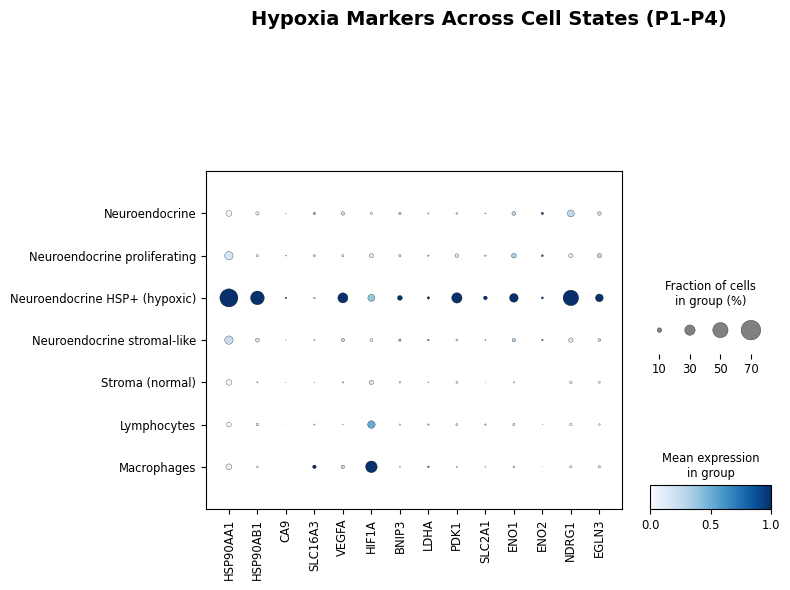


 Hypoxia Dotplot saved!


In [4]:
import matplotlib.pyplot as plt

print("="*80)
print("HYPOXIA MARKERS DOTPLOT (P1-P4)")
print("="*80)

#Use raw data & copy annotations
if adata.raw is not None:
    adata_raw = adata.raw.to_adata()
    adata_raw.obs = adata.obs.copy()
else:
    adata_raw = adata.copy()

print(f"Total cells before filtering: {adata_raw.n_obs}")
print(f"Total genes in raw: {adata_raw.n_vars}")

#Filter to P1-P4 as they share cell states (including NE HSP+)
adata_p1_p4 = adata_raw[adata_raw.obs['PatientID'].isin(['P1', 'P2', 'P3', 'P4'])].copy()

#Remove Amphicrine progenitor-like as its highly P5 specific 
adata_p1_p4 = adata_p1_p4[adata_p1_p4.obs['Cell states'] != 'Amphicrine progenitor-like'].copy()

print(f"\nAfter P1-P4 filter + removing Amphicrine: {adata_p1_p4.n_obs} cells")
print(f"Cell states present:\n{adata_p1_p4.obs['Cell states'].value_counts()}")

#Selected hypoxia + stress genes 
hypoxia_markers = ['HSP90AA1', 'HSP90AB1', 'CA9', 'SLC16A3', 'VEGFA', 'HIF1A', 'BNIP3', 'LDHA', 
                   'PDK1', 'SLC2A1', 'ENO1', 'ENO2', 'NDRG1', 'EGLN3']

print("\nChecking gene presence in P1-P4 subset:")
genes_available = []
for gene in hypoxia_markers:
    if gene in adata_p1_p4.var_names:
        print(f"✓ {gene} - FOUND")
        genes_available.append(gene)
    else:
        print(f"✗ {gene} - NOT FOUND")

if not genes_available:
    print("\n ERROR: No genes found! Checking what went wrong...")
    print(f"Sample of var_names: {list(adata_p1_p4.var_names[:20])}")
else:
    print(f"\n✓ Found {len(genes_available)} genes: {genes_available}")
    
    #Create dotplot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sc.pl.dotplot(
        adata_p1_p4,
        var_names=genes_available,
        groupby='Cell states',
        standard_scale='var',
        dot_max=0.7,
        cmap='Blues',
        ax=ax,
        show=False
    )
    
    ax.set_title('Hypoxia Markers Across Cell States (P1-P4)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./figures/hypoxia_markers_dotplot_P1-P4_corrected.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('./figures/hypoxia_markers_dotplot_P1-P4_corrected.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print("\n Hypoxia Dotplot saved!")